In [303]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [304]:
df = pd.read_csv('C:\\Users\\nikhi\\OneDrive\\Desktop\\tekworks\\project\\New folder\\knn_regression_dataset.csv')
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [305]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [306]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [307]:
df.columns

Index(['age', 'income', 'loan_amount', 'credit_score', 'city',
       'employment_type', 'target'],
      dtype='object')

In [308]:
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


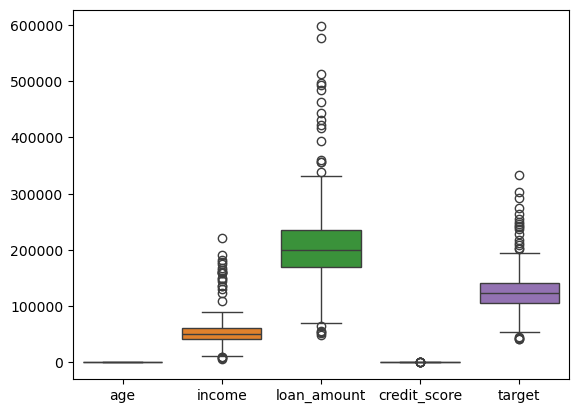

In [309]:
# box plot
sns.boxplot(data=df)
plt.show()

In [310]:
df['income'] = df['income'].fillna(df['income'].median())
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())

In [311]:
df.isnull().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

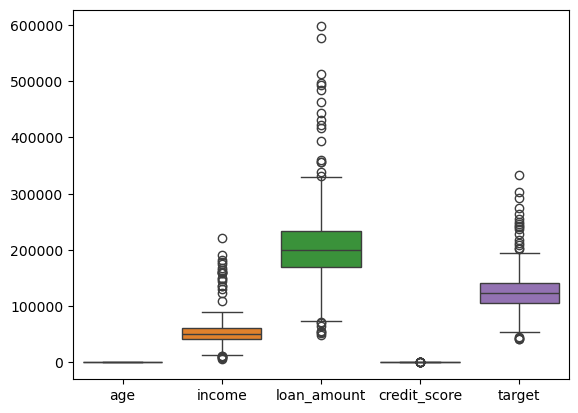

In [312]:
sns.boxplot(data=df)
plt.show()

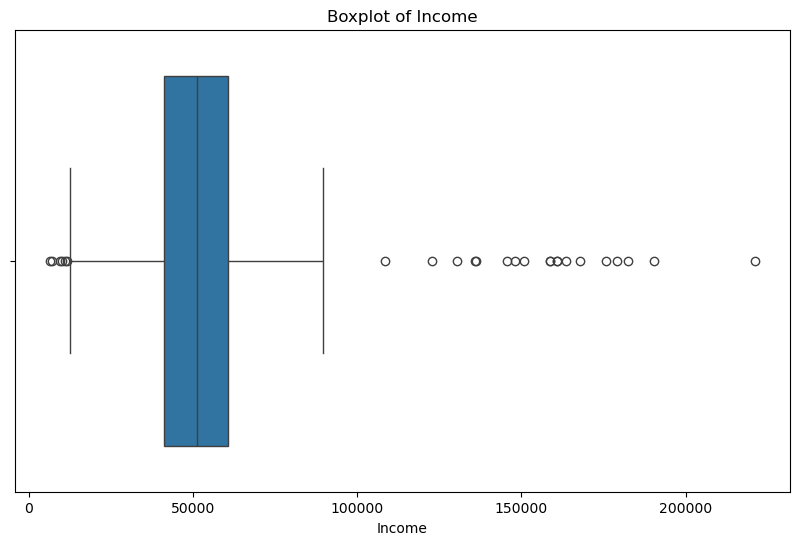

In [313]:
# check the outliers in income using box plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df['income']) 
plt.title('Boxplot of Income')
plt.xlabel('Income')
plt.show()

In [314]:
# remove the outliers in income using IQR method
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['income'] = df['income'].clip(lower_bound, upper_bound)


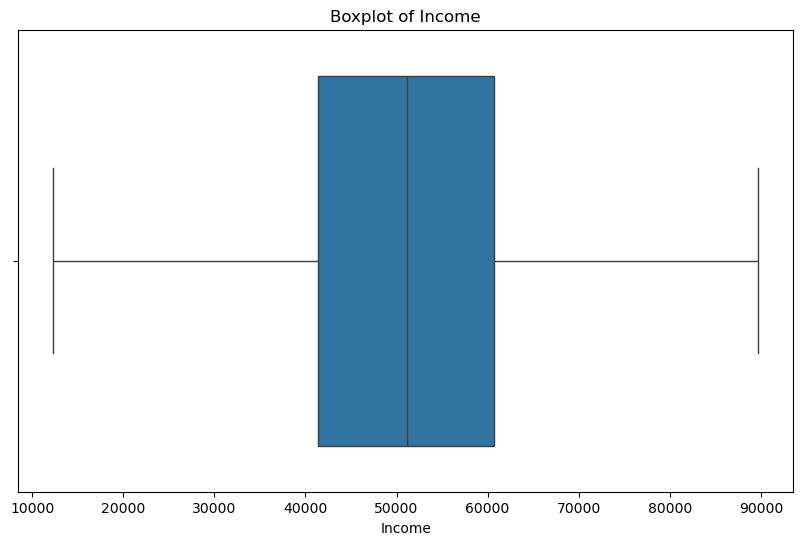

In [315]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['income']) 
plt.title('Boxplot of Income')
plt.xlabel('Income')
plt.show()

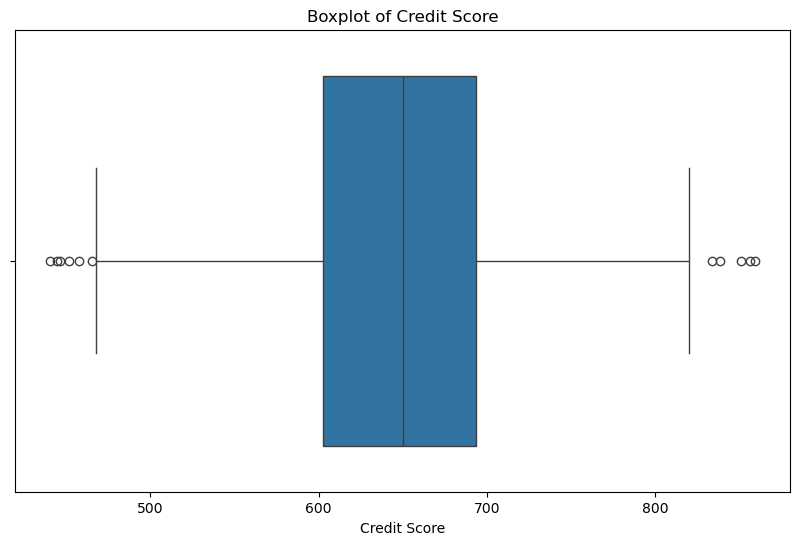

In [316]:
# check the outlier using box plot
plt.figure(figsize=(10,6))
sns.boxplot(x=df['credit_score'])
plt.title('Boxplot of Credit Score')
plt.xlabel('Credit Score')
plt.show()

In [317]:
# remove the outliers in credit_score using IQR method
Q1 = df['credit_score'].quantile(0.25)
Q3 = df['credit_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['credit_score'] = df['credit_score'].clip(lower_bound, upper_bound)

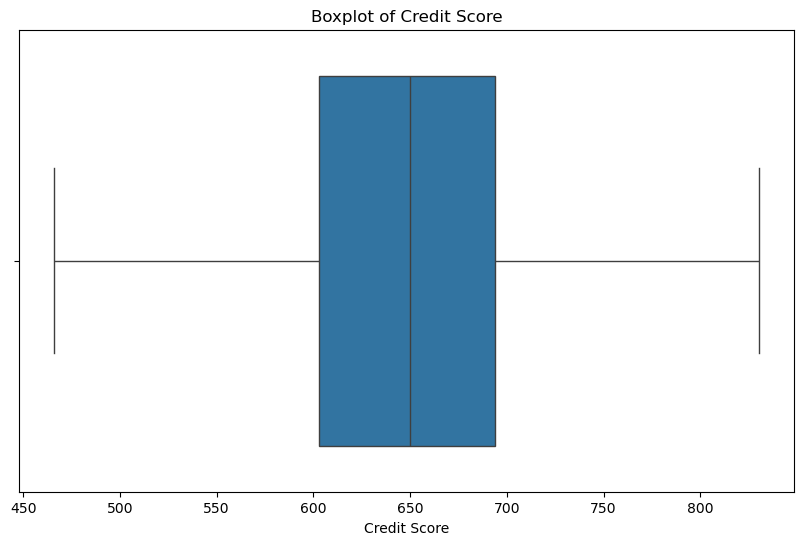

In [318]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['credit_score'])
plt.title('Boxplot of Credit Score')
plt.xlabel('Credit Score')
plt.show()

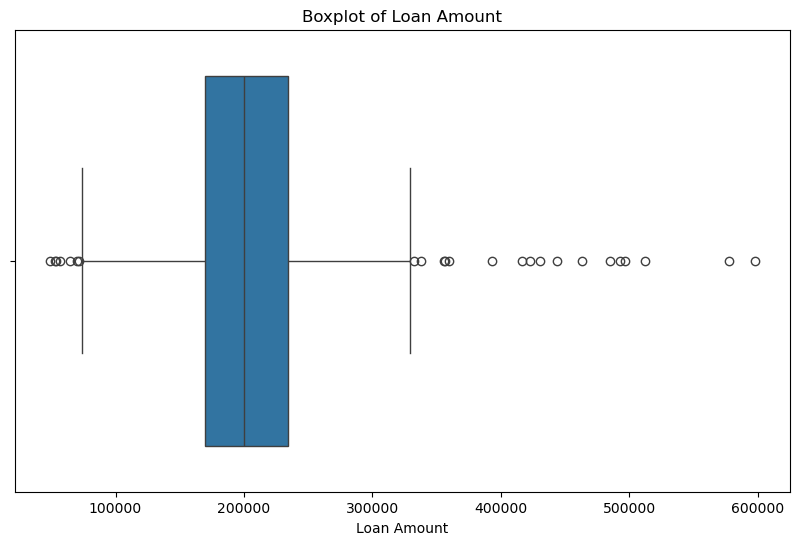

In [319]:
# check the outlier using box plot for loan_amount
plt.figure(figsize=(10,6))
sns.boxplot(x=df['loan_amount'])
plt.title('Boxplot of Loan Amount')
plt.xlabel('Loan Amount')
plt.show()

In [320]:
# remove the outliers in loan_amount using IQR method
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['loan_amount'] = df['loan_amount'].clip(lower_bound, upper_bound)

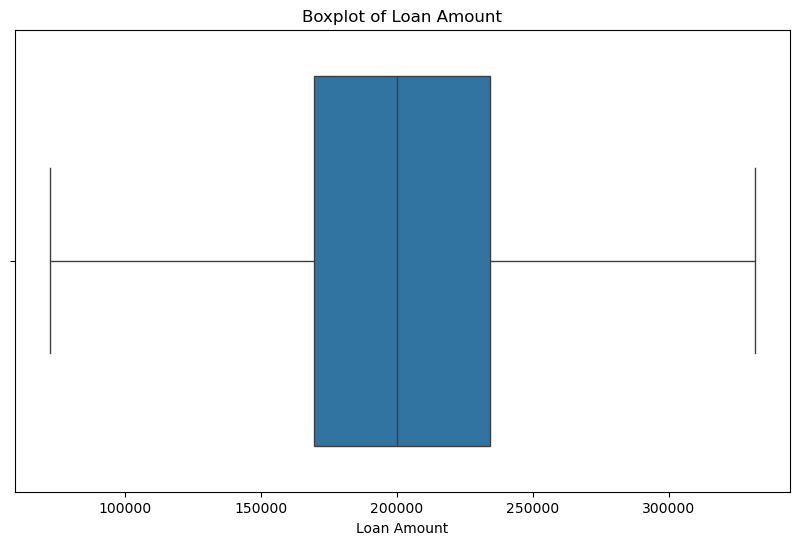

In [321]:
# check the outlier using box plot for loan_amount
plt.figure(figsize=(10,6))
sns.boxplot(x=df['loan_amount'])
plt.title('Boxplot of Loan Amount')
plt.xlabel('Loan Amount')
plt.show()

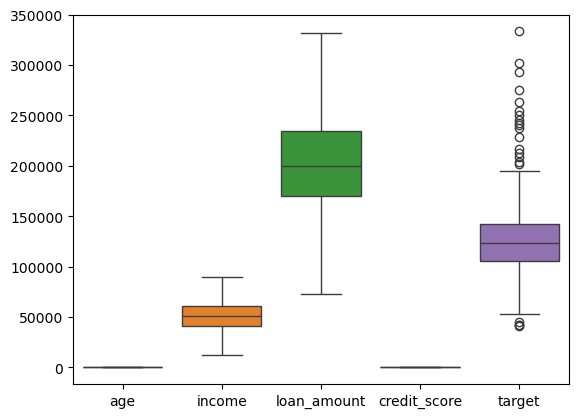

In [322]:
# sns boxplot
sns.boxplot(data=df)
plt.show()


In [323]:
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [324]:
"""df['employment_type'].value_counts()"""

"df['employment_type'].value_counts()"

In [325]:
""" # convert categorical variable to numerical variable 
df = pd.get_dummies(df, columns=['employment_type'], drop_first=False)
df.head()"""

" # convert categorical variable to numerical variable \ndf = pd.get_dummies(df, columns=['employment_type'], drop_first=False)\ndf.head()"

In [326]:
"""# convert true false to 1 and 0 for employment type
df['employment_type_Salaried'] = df['employment_type_Salaried'].map({True: 1, False: 0})
df['employment_type_Self-Employed'] = df['employment_type_Self-Employed'].map({True: 1, False: 0})
df['employment_type_Unemployed'] = df['employment_type_Unemployed'].map({True: 1, False: 0})
df.head()"""

"# convert true false to 1 and 0 for employment type\ndf['employment_type_Salaried'] = df['employment_type_Salaried'].map({True: 1, False: 0})\ndf['employment_type_Self-Employed'] = df['employment_type_Self-Employed'].map({True: 1, False: 0})\ndf['employment_type_Unemployed'] = df['employment_type_Unemployed'].map({True: 1, False: 0})\ndf.head()"

In [327]:
"""df['city'].value_counts()"""

"df['city'].value_counts()"

In [328]:
"""# convert categorical variable to numerical for city 
df = pd.get_dummies(df, columns=['city'], drop_first=False)
df.head()"""

"# convert categorical variable to numerical for city \ndf = pd.get_dummies(df, columns=['city'], drop_first=False)\ndf.head()"

In [329]:
"""# convert the true false to 1 and 0 for city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai
df['city_Bangalore'] = df['city_Bangalore'].map({True: 1, False: 0})
df['city_Chennai'] = df['city_Chennai'].map({True: 1, False: 0})
df['city_Hyderabad'] = df['city_Hyderabad'].map({True: 1, False: 0})
df['city_Mumbai'] = df['city_Mumbai'].map({True: 1, False: 0})
df.head()"""

"# convert the true false to 1 and 0 for city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai\ndf['city_Bangalore'] = df['city_Bangalore'].map({True: 1, False: 0})\ndf['city_Chennai'] = df['city_Chennai'].map({True: 1, False: 0})\ndf['city_Hyderabad'] = df['city_Hyderabad'].map({True: 1, False: 0})\ndf['city_Mumbai'] = df['city_Mumbai'].map({True: 1, False: 0})\ndf.head()"

In [330]:
df.shape

(1000, 7)

In [332]:
# handle the categorical variable by one hot encoding
cat=['city','employment_type']
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[cat])
encoded_data

array([[0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.]], shape=(1000, 7))

In [334]:
# encode_data converted to dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat))
encoded_df.head()

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [335]:
df=pd.concat([df.drop(columns=cat),encoded_df], axis=1)
df

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,40301.406736,129081.713353,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,60,51119.925190,272663.033166,502.604714,155285.942941,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,64,36687.617333,133069.710014,730.751324,65076.404995,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,62,43438.125495,234645.931152,747.044458,126006.462108,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,35,60835.720367,169706.958962,628.847359,118101.789665,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [337]:
# scale the columns 
skewness=df.drop(columns=['target']).skew()
skewness

age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [ ]:
df['date']=pd.to_datetime(df['date'])
df.info()